# W1-D2 · Foundations of Python for Data Science & Machine Learning
## UCAB · Faculty of Engineering
## School of Software Engineering
## **INFO-02020: Artificial Intelligence: Machine Learning**
### **Instructor:** Prof. Didi Ramsaran Chin  

In [ ]:
# uncomment below if running in colabh to install mglearn
# pip install mglearn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mglearn
from sklearn.datasets import load_diabetes, load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import SGDRegressor, SGDClassifier, LinearRegression
from sklearn.metrics import mean_squared_error, log_loss, accuracy_score, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPClassifier
import warnings

warnings.filterwarnings('ignore')

# Load datasets
diabetes = load_diabetes(as_frame=True)
df_diabetes = diabetes.frame

cancer = load_breast_cancer(as_frame=True)
df_cancer = cancer.frame

## Real dataset-based examples

In [3]:
# Display table for diabetes data
display(df_diabetes.head())
df_diabetes.info()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [8]:
# idem but for cancer data
display(df_cancer.head())
print("-"*100)
df_diabetes.info()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


----------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


diabetes statistics


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


----------------------------------------------------------------------------------------------------
cancer statistics


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


----------------------------------------------------------------------------------------------------
Plots for both datasets


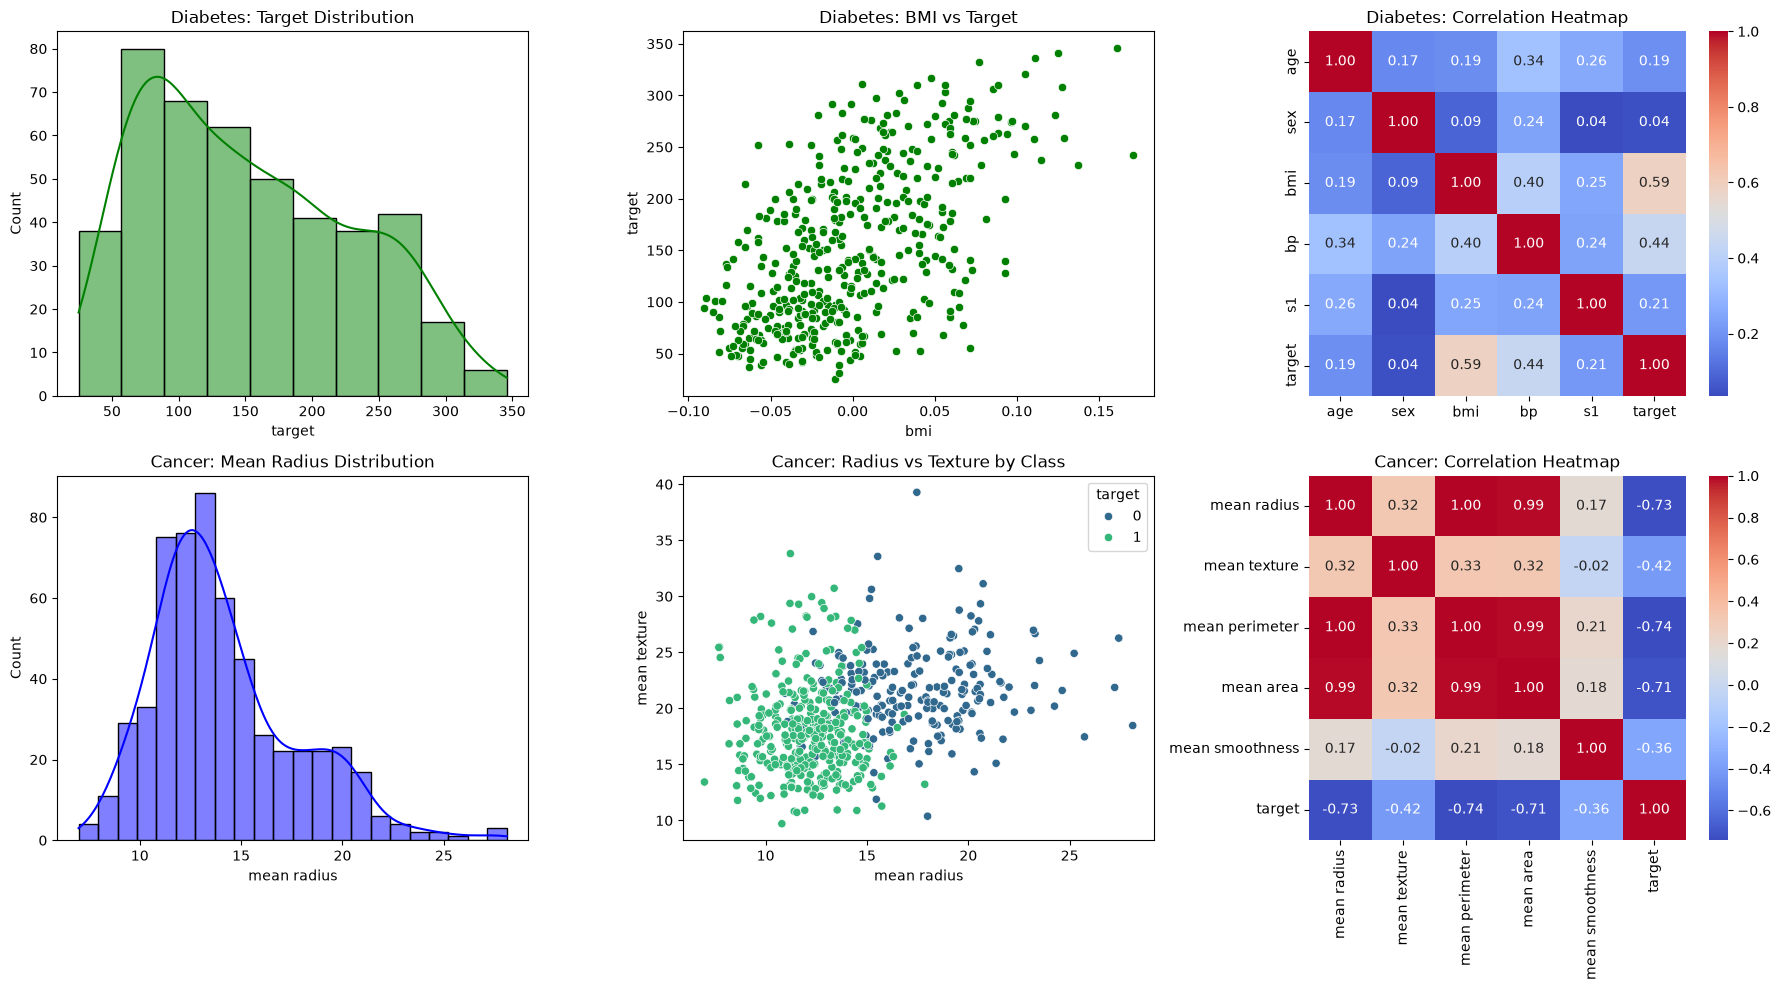

In [10]:
print("diabetes statistics")
display(df_diabetes.describe())

print("-"*100)
print("cancer statistics")
display(df_cancer.describe())

print("-"*100)
print("Plots for both datasets")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.histplot(df_diabetes['target'], kde=True, ax=axes[0, 0], color='green')
axes[0, 0].set_title('Diabetes: Target Distribution')

sns.scatterplot(x='bmi', y='target', data=df_diabetes, ax=axes[0, 1], color='green')
axes[0, 1].set_title('Diabetes: BMI vs Target')

corr_diabetes = df_diabetes[['age', 'sex', 'bmi', 'bp', 's1', 'target']].corr()
sns.heatmap(corr_diabetes, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0, 2])
axes[0, 2].set_title('Diabetes: Correlation Heatmap')

sns.histplot(df_cancer['mean radius'], kde=True, ax=axes[1, 0], color='blue')
axes[1, 0].set_title('Cancer: Mean Radius Distribution')

sns.scatterplot(x='mean radius', y='mean texture', hue='target', data=df_cancer, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Cancer: Radius vs Texture by Class')

corr_cancer = df_cancer[cancer.feature_names[:5].tolist() + ['target']].corr()
sns.heatmap(corr_cancer, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 2])
axes[1, 2].set_title('Cancer: Correlation Heatmap')

plt.tight_layout()
plt.show()

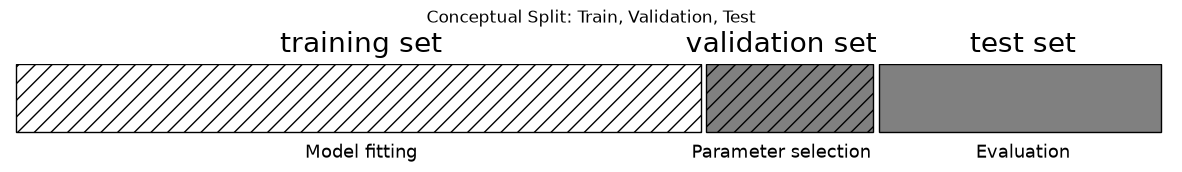

In [13]:
mglearn.plots.plot_threefold_split()
plt.title("Conceptual Split: Train, Validation, Test")
plt.show()

X_r, y_r = diabetes.data.values, diabetes.target.values
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_r, y_r, test_size=0.2, random_state=42)

X_c, y_c = cancer.data.values, cancer.target.values
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

In [16]:
n_splits = 4
n_epochs = 2000
kf_c = KFold(n_splits=n_splits, shuffle=True, random_state=42)
kf_r = KFold(n_splits=n_splits, shuffle=True, random_state=42)

classes_c = np.unique(y_c)

train_loss_c = np.zeros((n_splits, n_epochs))
val_loss_c = np.zeros((n_splits, n_epochs))
train_acc_c = np.zeros((n_splits, n_epochs))
val_acc_c = np.zeros((n_splits, n_epochs))
test_acc_c = np.zeros((n_splits, n_epochs))

train_loss_r = np.zeros((n_splits, n_epochs))
val_loss_r = np.zeros((n_splits, n_epochs))
train_r2_r = np.zeros((n_splits, n_epochs))
val_r2_r = np.zeros((n_splits, n_epochs))
test_r2_r = np.zeros((n_splits, n_epochs))

splits_c = kf_c.split(X_train_c_scaled)
splits_r = kf_r.split(X_train_r_scaled)

for fold, ((train_idx_c, val_idx_c), (train_idx_r, val_idx_r)) in enumerate(zip(splits_c, splits_r)):
    model_c = SGDClassifier(loss='log_loss', learning_rate='constant', eta0=0.001, random_state=42)
    model_r = SGDRegressor(loss='squared_error', learning_rate='constant', eta0=0.001, random_state=42)

    X_fold_train_c, y_fold_train_c = X_train_c_scaled[train_idx_c], y_train_c[train_idx_c]
    X_fold_val_c, y_fold_val_c = X_train_c_scaled[val_idx_c], y_train_c[val_idx_c]

    X_fold_train_r, y_fold_train_r = X_train_r_scaled[train_idx_r], y_train_r[train_idx_r]
    X_fold_val_r, y_fold_val_r = X_train_r_scaled[val_idx_r], y_train_r[val_idx_r]

    for epoch in range(n_epochs):
        model_c.partial_fit(X_fold_train_c, y_fold_train_c, classes=classes_c)
        y_train_prob_c = model_c.predict_proba(X_fold_train_c)
        y_val_prob_c = model_c.predict_proba(X_fold_val_c)
        y_train_pred_c = model_c.predict(X_fold_train_c)
        y_val_pred_c = model_c.predict(X_fold_val_c)
        y_test_pred_c = model_c.predict(X_test_c_scaled)

        train_loss_c[fold, epoch] = log_loss(y_fold_train_c, y_train_prob_c)
        val_loss_c[fold, epoch] = log_loss(y_fold_val_c, y_val_prob_c)
        train_acc_c[fold, epoch] = accuracy_score(y_fold_train_c, y_train_pred_c)
        val_acc_c[fold, epoch] = accuracy_score(y_fold_val_c, y_val_pred_c)
        test_acc_c[fold, epoch] = accuracy_score(y_test_c, y_test_pred_c)

        model_r.partial_fit(X_fold_train_r, y_fold_train_r)
        y_train_pred_r = model_r.predict(X_fold_train_r)
        y_val_pred_r = model_r.predict(X_fold_val_r)
        y_test_pred_r = model_r.predict(X_test_r_scaled)

        train_loss_r[fold, epoch] = mean_squared_error(y_fold_train_r, y_train_pred_r)
        val_loss_r[fold, epoch] = mean_squared_error(y_fold_val_r, y_val_pred_r)
        train_r2_r[fold, epoch] = r2_score(y_fold_train_r, y_train_pred_r)
        val_r2_r[fold, epoch] = r2_score(y_fold_val_r, y_val_pred_r)
        test_r2_r[fold, epoch] = r2_score(y_test_r, y_test_pred_r)

mean_train_loss_c = train_loss_c.mean(axis=0)
mean_val_loss_c = val_loss_c.mean(axis=0)
mean_train_acc_c = train_acc_c.mean(axis=0)
mean_val_acc_c = val_acc_c.mean(axis=0)
mean_test_acc_c = test_acc_c.mean(axis=0)

mean_train_loss_r = train_loss_r.mean(axis=0)
mean_val_loss_r = val_loss_r.mean(axis=0)
mean_train_r2_r = train_r2_r.mean(axis=0)
mean_val_r2_r = val_r2_r.mean(axis=0)
mean_test_r2_r = test_r2_r.mean(axis=0)

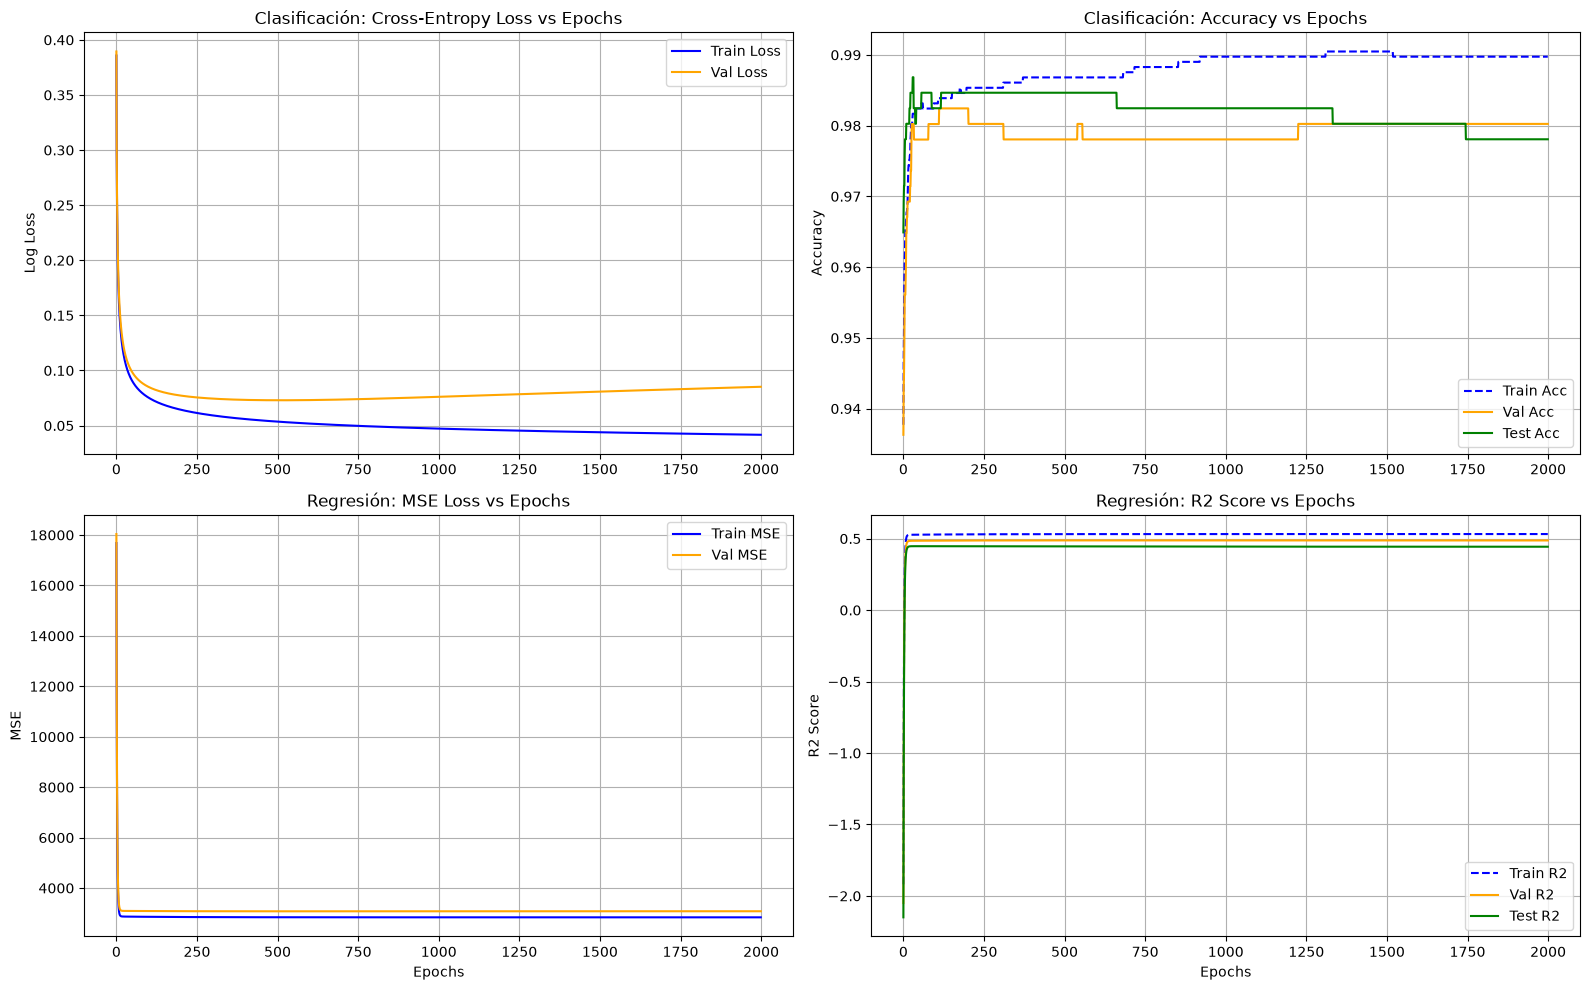

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(range(n_epochs), mean_train_loss_c, label='Train Loss', color='blue')
axes[0, 0].plot(range(n_epochs), mean_val_loss_c, label='Val Loss', color='orange')
axes[0, 0].set_title('Clasificación: Cross-Entropy Loss vs Epochs')
axes[0, 0].set_ylabel('Log Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(range(n_epochs), mean_train_acc_c, label='Train Acc', color='blue', linestyle='--')
axes[0, 1].plot(range(n_epochs), mean_val_acc_c, label='Val Acc', color='orange')
axes[0, 1].plot(range(n_epochs), mean_test_acc_c, label='Test Acc', color='green')
axes[0, 1].set_title('Clasificación: Accuracy vs Epochs')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(range(n_epochs), mean_train_loss_r, label='Train MSE', color='blue')
axes[1, 0].plot(range(n_epochs), mean_val_loss_r, label='Val MSE', color='orange')
axes[1, 0].set_title('Regresión: MSE Loss vs Epochs')
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('MSE')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(range(n_epochs), mean_train_r2_r, label='Train R2', color='blue', linestyle='--')
axes[1, 1].plot(range(n_epochs), mean_val_r2_r, label='Val R2', color='orange')
axes[1, 1].plot(range(n_epochs), mean_test_r2_r, label='Test R2', color='green')
axes[1, 1].set_title('Regresión: R2 Score vs Epochs')
axes[1, 1].set_xlabel('Epochs')
axes[1, 1].set_ylabel('R2 Score')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

it is difficult to visualize the trade-off with alinear regression, we will use two sinthetic approaches instead.

## Sithetic-data example of bias-variance trade

### Polynomial approximations

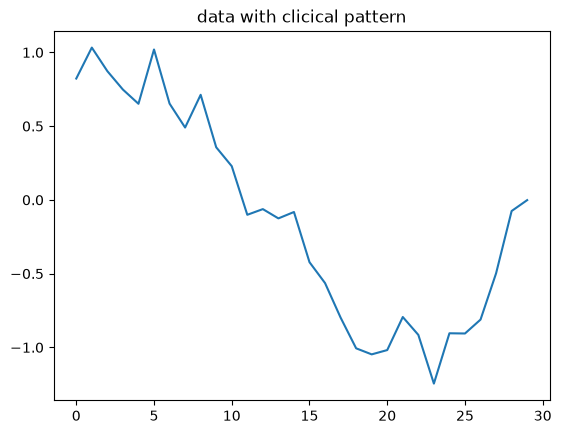

In [32]:
# sinusoidal like wawe based on cosine
np.random.seed(42)
n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = np.cos(1.5 * np.pi * X) + np.random.randn(n_samples) * 0.15
X = X[:, np.newaxis]

plt.plot(y)
plt.title('data with clicical pattern')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

degrees = [1, 4, 15]
X_plot = np.linspace(0, 1, 100)[:, np.newaxis]
y_true = np.cos(1.5 * np.pi * X_plot)

predictions = {}
train_mse = {}
test_mse = {}

for degree in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        StandardScaler(),
        LinearRegression()
    )
    model.fit(X_train, y_train)

    predictions[degree] = model.predict(X_plot)
    train_mse[degree] = mean_squared_error(y_train, model.predict(X_train))
    test_mse[degree] = mean_squared_error(y_test, model.predict(X_test))

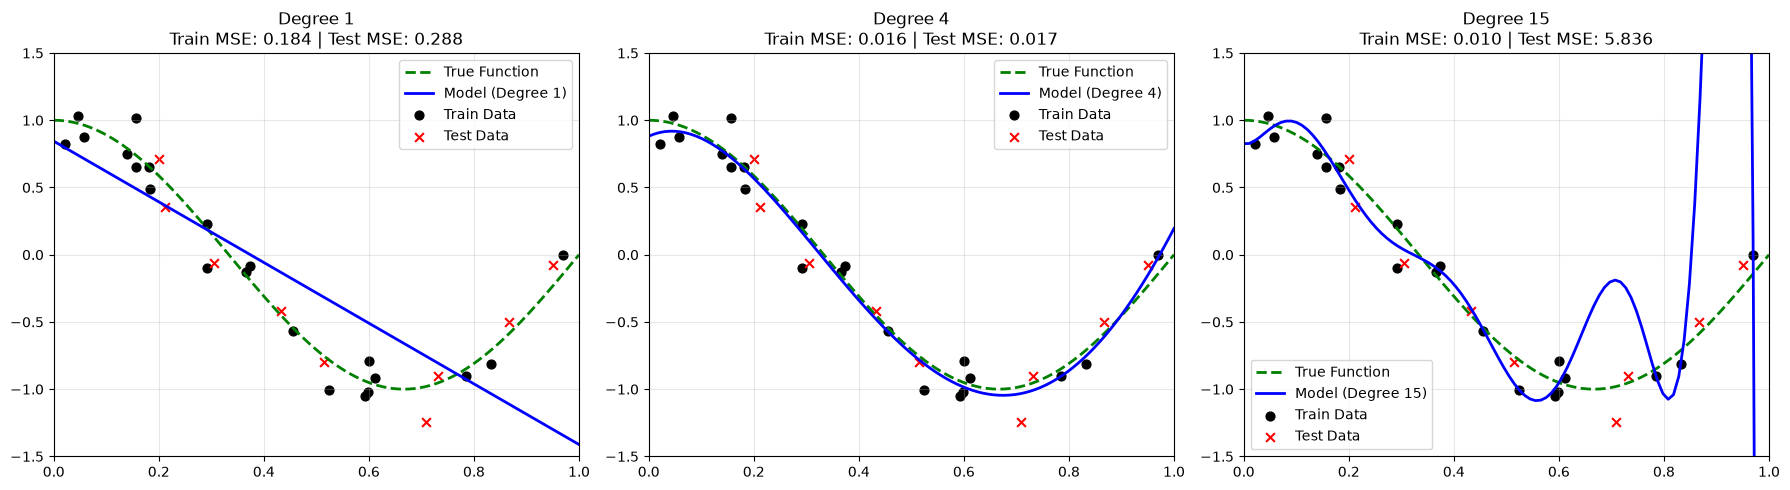

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, degree in enumerate(degrees):
    ax = axes[i]

    ax.plot(X_plot, y_true, color='green', linestyle='--', linewidth=2, label='True Function')
    ax.plot(X_plot, predictions[degree], color='blue', linewidth=2, label=f'Model (Degree {degree})')
    ax.scatter(X_train, y_train, color='black', s=40, label='Train Data')
    ax.scatter(X_test, y_test, color='red', s=40, marker='x', label='Test Data')

    ax.set_ylim(-1.5, 1.5)
    ax.set_xlim(0, 1)
    ax.set_title(f'Degree {degree}\nTrain MSE: {train_mse[degree]:.3f} | Test MSE: {test_mse[degree]:.3f}')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Synthetic-data example of bias-variance trade

In [33]:
# Suprimir advertencias de partial_fit para mantener la consola limpia
warnings.filterwarnings('ignore')

# Generamos un dataset ruidoso, ideal para forzar el overfitting
X, y = make_moons(n_samples=800, noise=0.35, random_state=42)

# División: 40% Entrenamiento, 30% Validación, 30% Prueba
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.4, random_state=42)

In [34]:
# MLP con alta capacidad (2 capas ocultas de 150 neuronas) y sin regularización (alpha=0)
model = MLPClassifier(hidden_layer_sizes=(150, 150), activation='relu',
                      solver='adam', alpha=0.0, learning_rate_init=0.005,
                      random_state=42)

n_epochs = 500
classes = np.unique(y)

train_acc, val_acc, test_acc = np.zeros(n_epochs), np.zeros(n_epochs), np.zeros(n_epochs)
train_loss, val_loss, test_loss = np.zeros(n_epochs), np.zeros(n_epochs), np.zeros(n_epochs)

for epoch in range(n_epochs):
    # partial_fit avanza el modelo exactamente 1 época
    model.partial_fit(X_train, y_train, classes=classes)

    # Probabilidades para calcular la función de pérdida (Log Loss)
    y_train_prob = model.predict_proba(X_train)
    y_val_prob = model.predict_proba(X_val)
    y_test_prob = model.predict_proba(X_test)

    # Predicciones discretas para calcular la exactitud (Accuracy)
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    # Registro de métricas
    train_loss[epoch] = log_loss(y_train, y_train_prob)
    val_loss[epoch] = log_loss(y_val, y_val_prob)
    test_loss[epoch] = log_loss(y_test, y_test_prob)

    train_acc[epoch] = accuracy_score(y_train, y_train_pred)
    val_acc[epoch] = accuracy_score(y_val, y_val_pred)
    test_acc[epoch] = accuracy_score(y_test, y_test_pred)

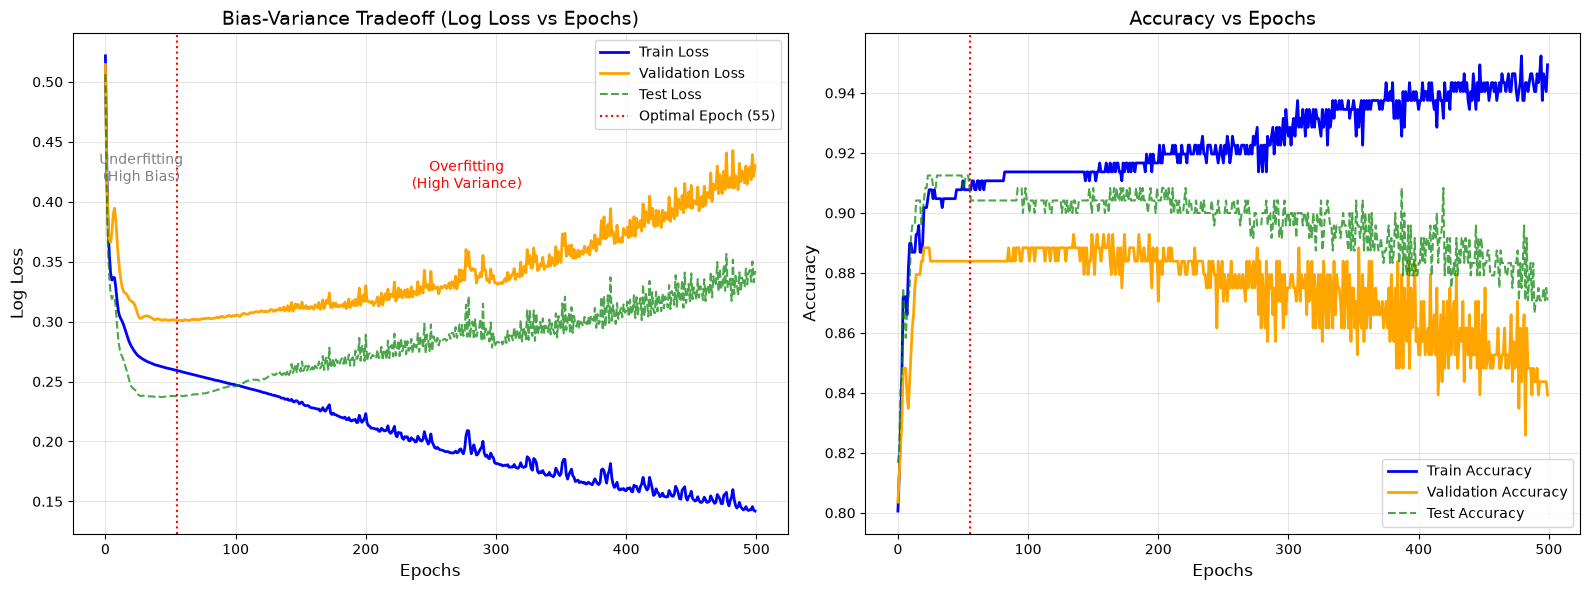

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# best epochs according to validation
best_epoch = np.argmin(val_loss)

# ploting of loss as a function of epochs for training, validation and testing
axes[0].plot(train_loss, label='Train Loss', color='blue', linewidth=2)
axes[0].plot(val_loss, label='Validation Loss', color='orange', linewidth=2)
axes[0].plot(test_loss, label='Test Loss', color='green', linestyle='--', alpha=0.7)
axes[0].axvline(x=best_epoch, color='red', linestyle=':', label=f'Optimal Epoch ({best_epoch})')

axes[0].set_title('Bias-Variance Tradeoff (Log Loss vs Epochs)', fontsize=14)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Log Loss', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Annotations
axes[0].text(best_epoch/2, max(train_loss)*0.8, 'Underfitting\n(High Bias)', ha='center', color='gray')
axes[0].text(best_epoch + (n_epochs-best_epoch)/2, max(val_loss)*0.8, 'Overfitting\n(High Variance)', ha='center', color='red')

# idem but all for accuracy as a function of epochs
axes[1].plot(train_acc, label='Train Accuracy', color='blue', linewidth=2)
axes[1].plot(val_acc, label='Validation Accuracy', color='orange', linewidth=2)
axes[1].plot(test_acc, label='Test Accuracy', color='green', linestyle='--', alpha=0.7)
axes[1].axvline(x=best_epoch, color='red', linestyle=':')

axes[1].set_title('Accuracy vs Epochs', fontsize=14)
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()